# [LAB 07] 4. 대응표본 T-Test
## #01. 준비작업
### 1. 패키지 설치

In [1]:
%pip install --upgrade statannotations

Note: you may need to restart the kernel to use updated packages.


### 2. 라이브러리 참조

In [2]:
from hossam import load_data
from helpers import my_plot, my_stats
from pandas import melt, DataFrame

# 가설 검정 가정에 따른 검정 방법 선택을 위한 라이브러리
from scipy.stats import t, ttest_rel, wilcoxon

# 시각화에 필요한 라이브러리
from statannotations.Annotator import Annotator

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.19


## #02.예제(1)- 사슴의 다리 길이 비교
### 1. 데이터 가져오기
- 사슴의 왼쪽 앞다리와 왼쪽 뒷다리의 길이를 측정한 자료를 통해 두 다리의 길이(cm)가 같은지 다른지 알고 싶다.
- 유의수준 0.05에서 검정하라

In [3]:
df1=load_data("deer")
df1.head()

📚 사슴의 왼쪽 앞다리와 왼쪽 뒷다리의 길이를 측정한 자료 (출처: 방송통신대학교 통계학개론)


,앞다리,뒷다리
사슴,,
1,138,142
2,136,140
3,147,144
4,139,144
5,143,142


### 2. 시각화를 위해 long 타입으로 데이터 재배치

In [4]:
df1_melt = melt(df1, var_name='group', value_name='length')
df1_melt.head()

,group,length
0,앞다리,138
1,앞다리,136
2,앞다리,147
3,앞다리,139
4,앞다리,143


### 3. 데이터 분포 시각화

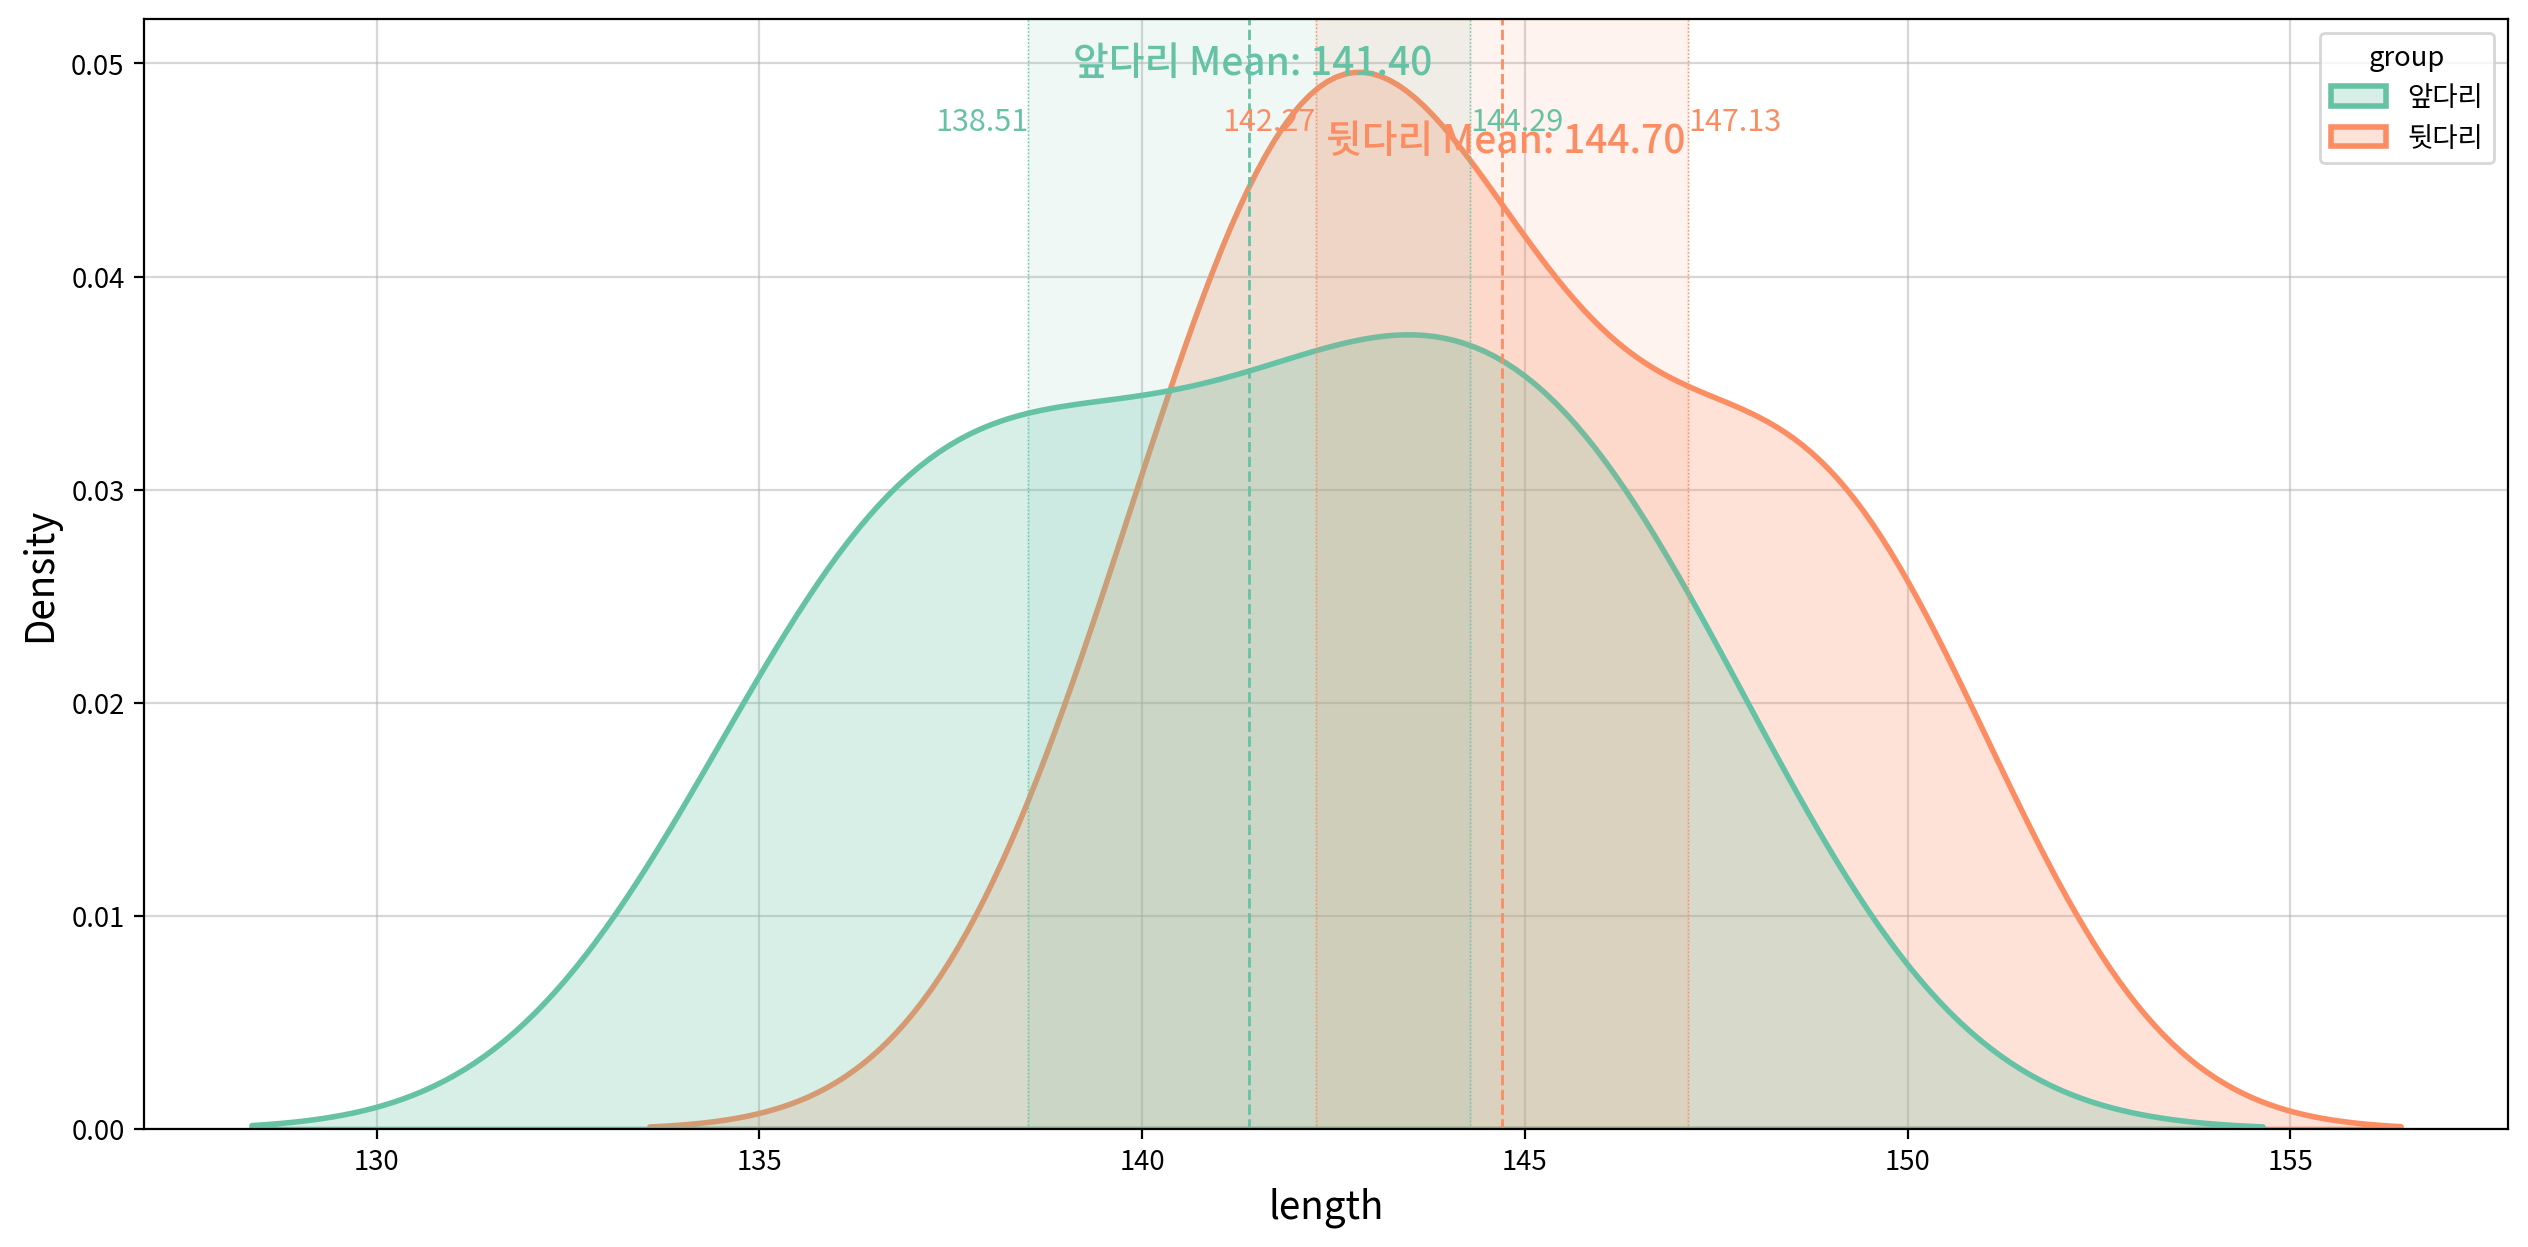

In [5]:
my_plot.kdeplot(data=df1_melt, x='length', hue='group', fill=True, meanline=True, clevel=0.95, palette='Set2')

### 4. 가설검정의 가정을 확인하기 위한 파생변수 생성
- 대응표본은 after에서 before를 뺀 값에 대하여 정규성을 검정해야 한다.

In [6]:
df1_diff = df1.copy()
df1_diff['diff'] = df1_diff['뒷다리'] - df1_diff['앞다리']
df1_diff.head()

,앞다리,뒷다리,diff
사슴,,,
1,138,142,4
2,136,140,4
3,147,144,-3
4,139,144,5
5,143,142,-1


### 5. 차이값에 대한 정규성 검정

In [7]:
my_stats.test_assumptions(data=df1_diff, columns='diff')

,test,statistic,p-value,result
field,,,,
diff,normaltest,4.356,0.113,True


- 정규성을 충족하므로 Paired T-Test를 수행한다.

### 6. Paired T-Test - 양측검정
- 사슴의 앞다리와 뒷다리의 길이가 다른지 검정
    - 두 그룹간의 평균을 비교하기 위해서는 alternative 파라미터를 two-sided로 설정한다.
    - 기본값이므로 생략 가능함

In [8]:
s, p = ttest_rel(df1['앞다리'], df1['뒷다리'], alternative='two-sided')
print(f't-statistic: {s:.4f}, p-value: {p:.4f}')

t-statistic: -3.4138, p-value: 0.0077


- 차이값에 대한 양측검정 수행 결과 귀무가설을 기각하고 대립가설을 채택한다.(p < 0.05)
- 즉, 사슴의 앞다리와 뒷다리의 길이는 통계적으로 유의한 차이가 있다.

### 7. Paired T-Test -좌측 단측검정
- 사슴의 앞다리가 뒷다리보다 짧은지 검정
    - 두 그룹간의 평균을 비교하기 위해서는 alternative 파라미터를 less로 설정한다.

In [9]:
s, p = ttest_rel(df1['앞다리'], df1['뒷다리'], alternative='less')
print(f't-statistic: {s:.4f}, p-value: {p:.4f}')

t-statistic: -3.4138, p-value: 0.0039


- 차이값에 대한 좌측 단측검정 수행 결과 귀무가설을 기각하고 대립가설을 채택한다.(p < 0.05)
- 즉, 사슴의 앞다리 길이는 뒷다리 길이보다 통계적으로 유의하게 짧다.

### 8. Paired T-Test - 우측 단측검정
- 사슴의 앞다리가 뒷다리보다 긴지 검정
    - 두 그룹간의 평균을 비교하기 위해서는 alternative 파라미터를 greater로 설정한다.

In [10]:
s, p = ttest_rel(df1['앞다리'], df1['뒷다리'], alternative='greater')
print(f't-statistic: {s:.4f}, p-value: {p:.4f}')

t-statistic: -3.4138, p-value: 0.9961


- 차이값에 대한 우측측 단측검정 수행 결과 귀무가설을 기각하고 대립가설을 채택한다.(p >= 0.05)
- 즉, 사슴의 앞다리 길이는 뒷다리 길이보다 통계적으로 유의하게 길다고 할 수 없다.

### 9. 가설검정 시각화
- 상자그렘에 Annotator 클래스의 객체를 사용하여 평균 비교를 추가할 수 있다.
    - 양측 검정만 지원하고 단측 검정은 지원하지 않음

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

앞다리 vs. 뒷다리: t-test paired samples, P_val:7.703e-03 t=-3.414e+00


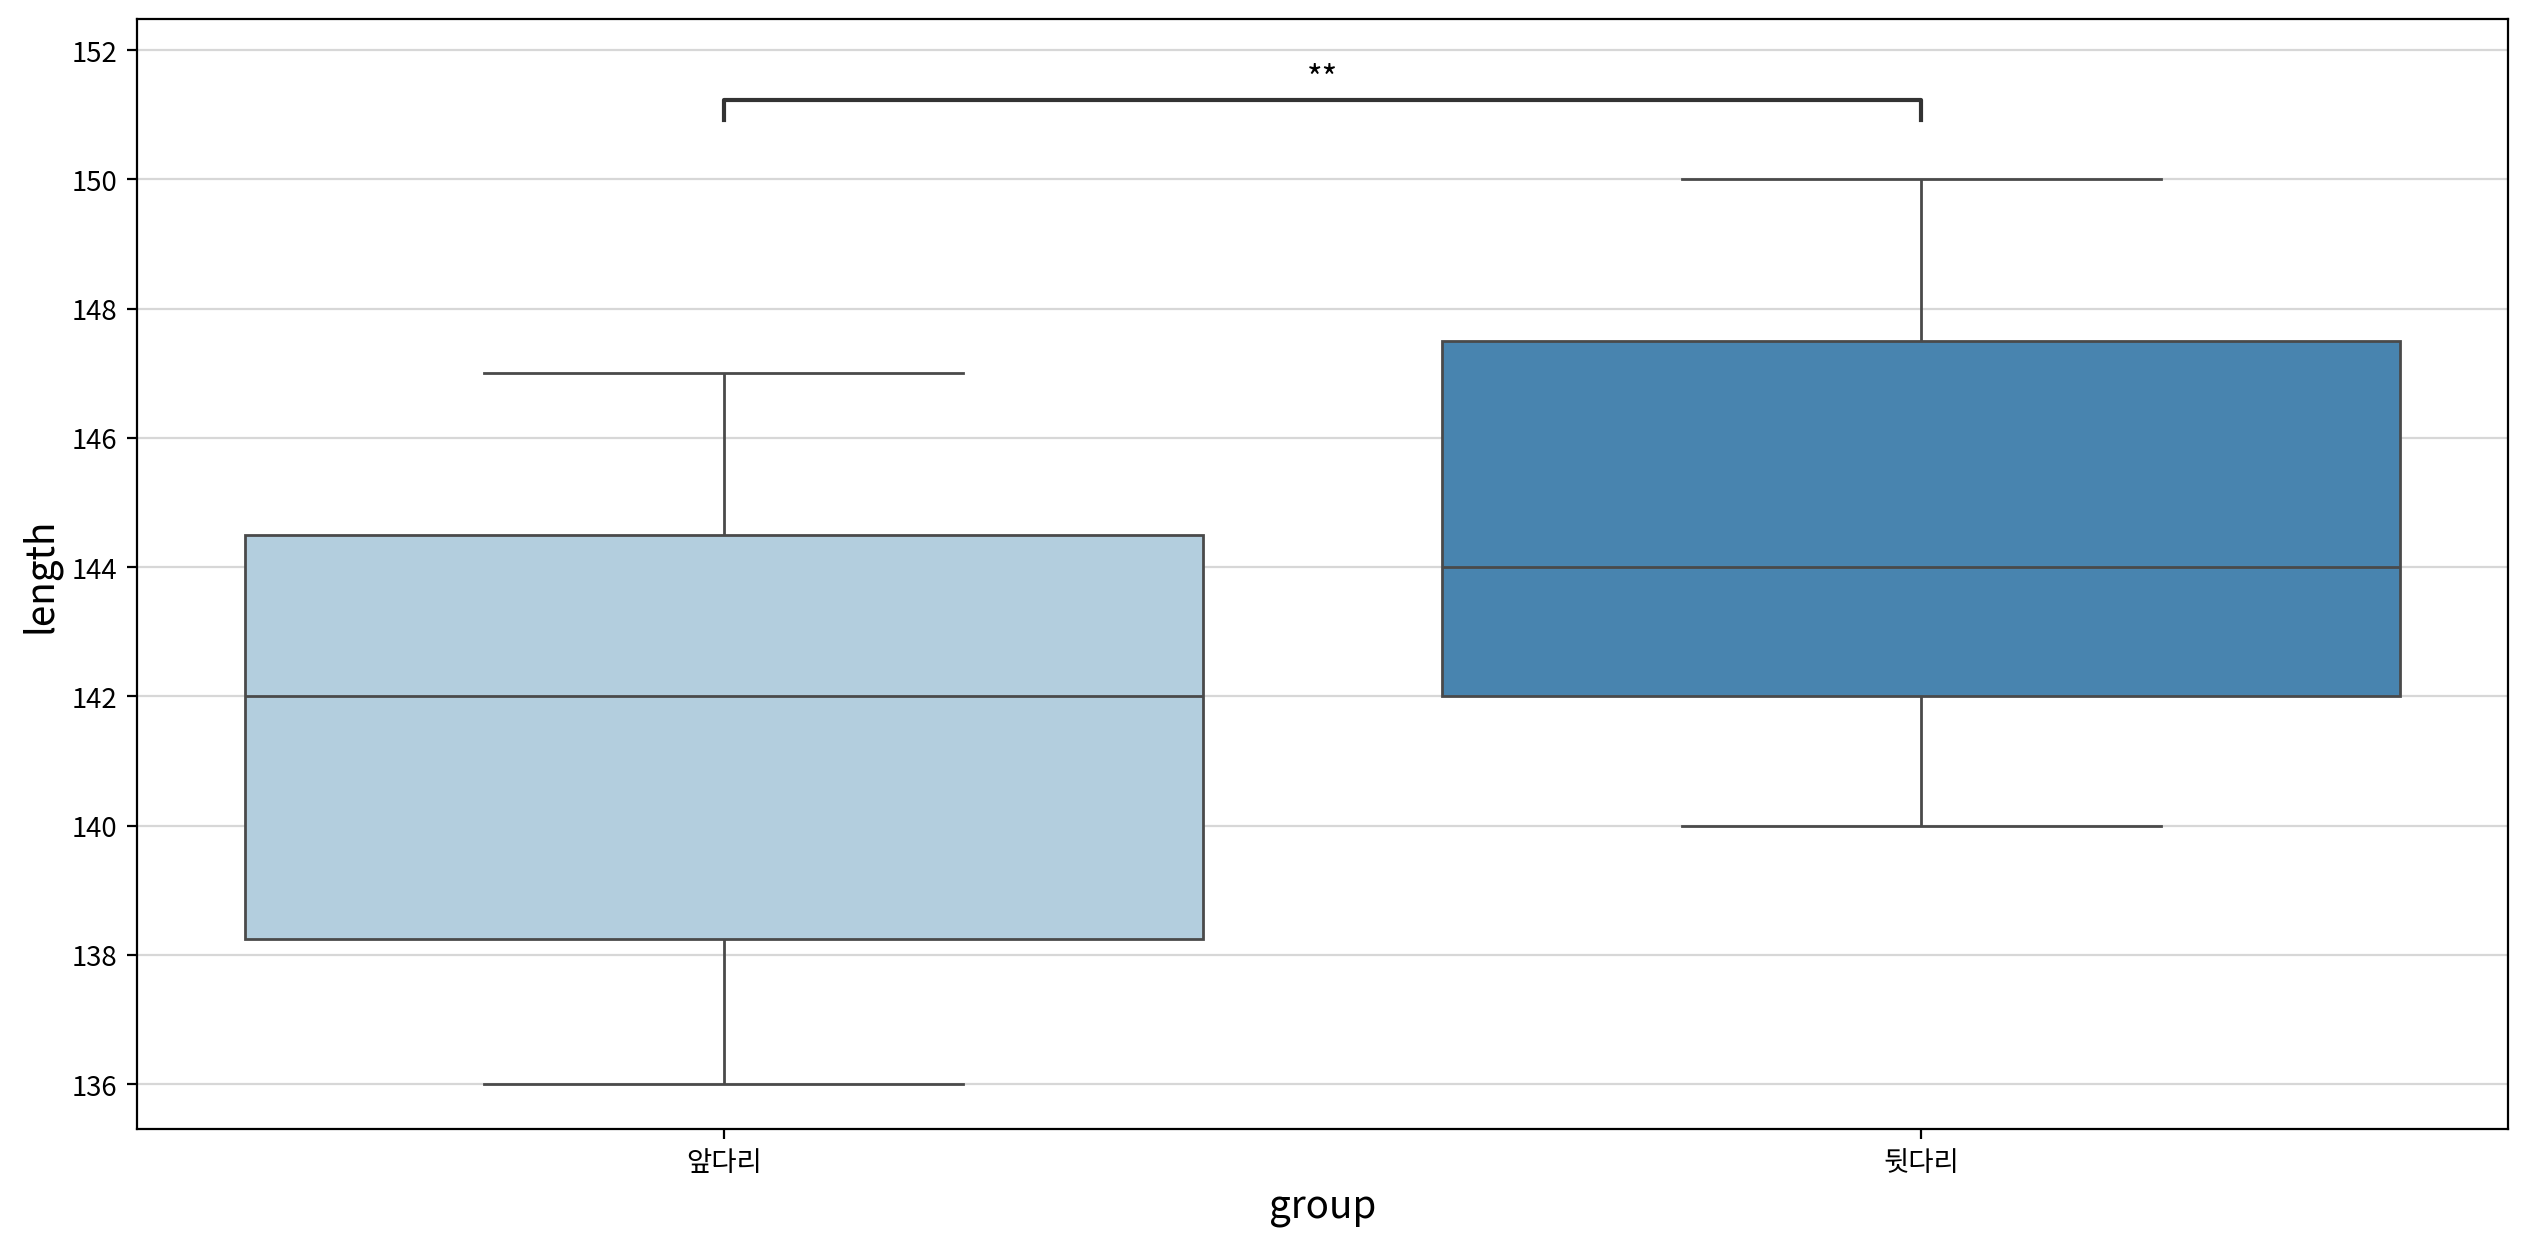

In [11]:
fig, ax = my_plot.init()
my_plot.boxplot(data=df1_melt, x='group', y='length', hue='group', palette='Blues', ax=ax)

# 독립표본 T검정 결과를 시각화에 추가
annotator = Annotator(data=df1_melt,              #데이터프레임
                      x='group',                  # x축 변수
                      y='length',                 # y축 변수
                      pairs=[('앞다리','뒷다리')], #비교할 그룹 쌍
                      ax=ax)                      # 그래프 축

# 가설검정 알고리즘 종류 ('t-test_ind', 't-test-paired', 't-test_welch', 'Mann-Whitney', 'Mann-Whitney-gh', 'Mann-Whitney-ls', 'Levene', 'wilcoxon', 'Kruskal' 등을 지원)
annotator.configure(test='t-test_paired')
annotator.apply_and_annotate()

my_plot.show()


## #03. 예제(2) - 자동차 첨가제가 주행거리에 미치는 영향
### 1. 데이터 가져오기
- 다섯 종류의 새 차에 대하여 같은 종류의 차 두대 중에서 한 대를 랜덤하게 선택하여 첨가제를 사용하고, 다른 한대에는 첨가제를 사용하지 않고 같은 운전자가 같은 장소에서 운전한 결과 다음과 같은 자료를 얻었다.
    - 첨가제를 사용하면 주행거리가 늘어난다고 할 수 있는지 유의수준 5%에서 검정하여 보라.
    - 그룹 A: 첨가제를 사용한 경우, 그룹 B: 첨가제를 사용하지 않은 경우

In [12]:
df2 = load_data('oil')
df2.head()

📚 다섯 종류의 새 차에 대하여 같은 종류의 차 두 대 중에서 한 대를 랜덤하게 선택하여 첨가제를 사용하고, 다른 한 대에는 첨가제를 사용하지 않고 같은 운전자가 같은 장소에서 운전한 후 주행거리를 측정한 결과 데이터 (출처: 방송통신대학교 통계학개론)


,그룹A,그룹B
0,13.200,11.700
1,13.100,17.984
2,16.300,12.290
3,14.900,9.862
4,14.200,8.871


### 2. 시각화를 위한 데이터 재배치
- melt 함수를 사용하여 wide형 데이터를 long형으로 변환한다.

In [13]:
df2_melt = melt(df2, var_name='group', value_name='length')
df2_melt.head()

,group,length
0,그룹A,13.200
1,그룹A,13.100
2,그룹A,16.300
3,그룹A,14.900
4,그룹A,14.200


### 3. 데이터 분포 시각화

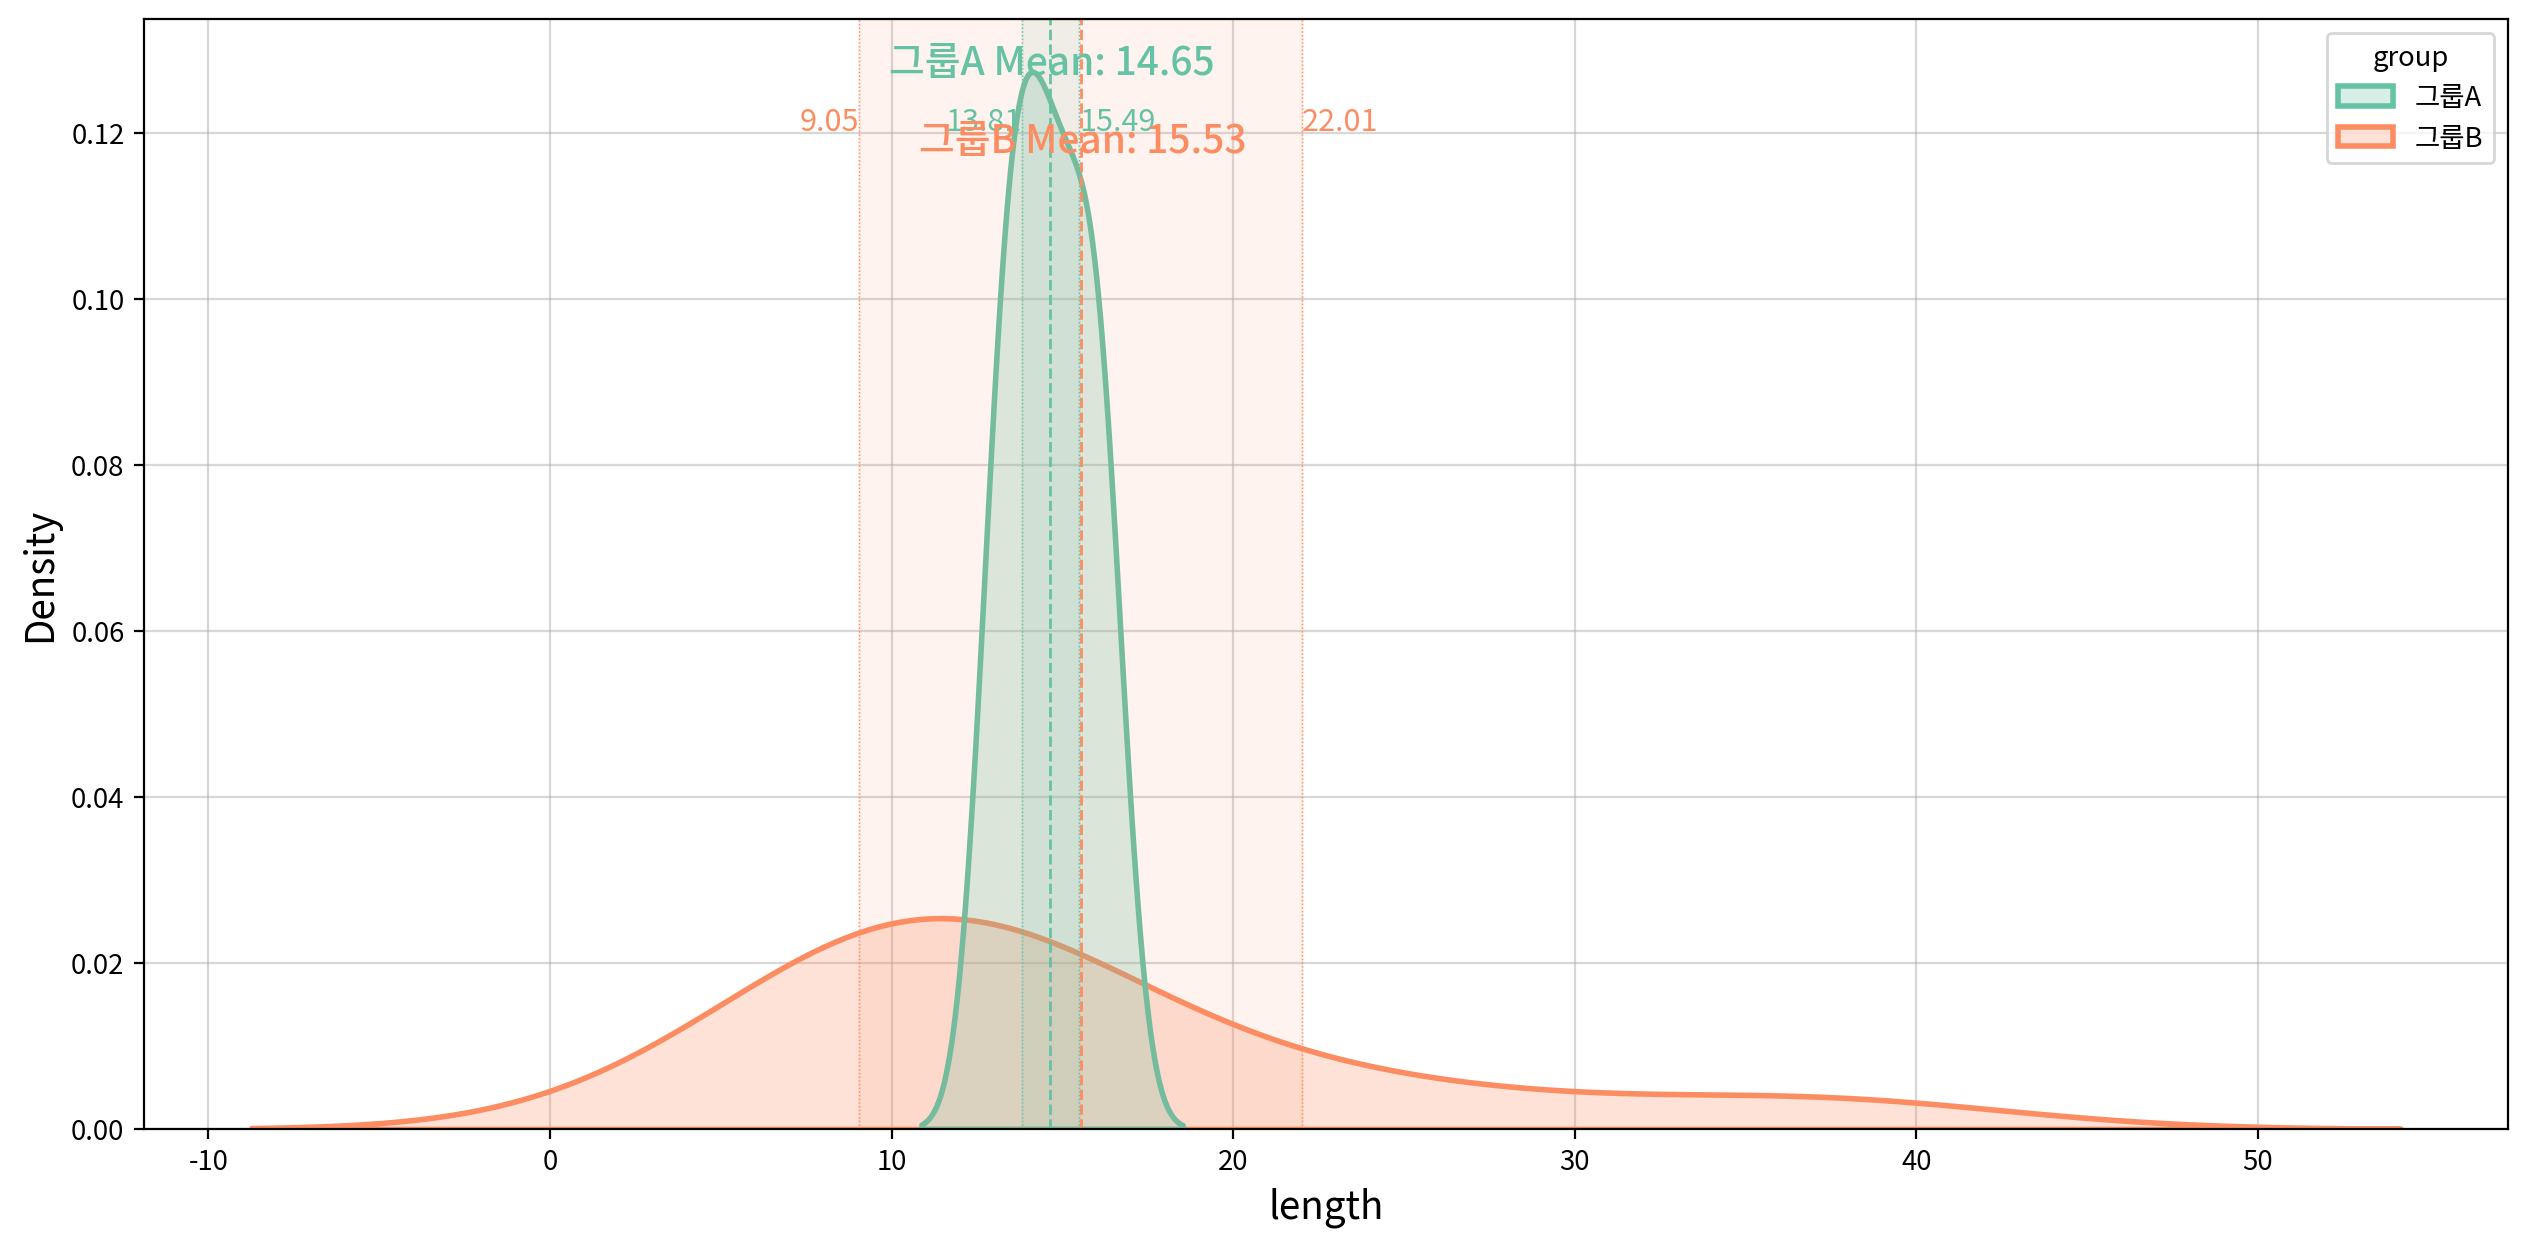

In [14]:
my_plot.kdeplot(data=df2_melt, x='length', hue='group', fill=True, meanline=True, clevel=0.95, palette='Set2')

- 인사이트 
    - 그룹A는 정규분포 모양을 띄지만 그룹B는 약한 우측꼬리 형태를 띄고 있어 정규성 가정을 충족하지 않는다.
    - 또한 두 그룹의 분산(데이터의 퍼짐 정도)가 극명하게 다르다.

### 4. 가설검정 가정 확인

In [15]:
# 차이값 계산
df2_diff = df2.copy()
df2_diff['diff'] = df2_diff['그룹A'] - df2_diff['그룹B']

# 차이에 대한 정규성 검정
my_stats.test_assumptions(data=df2_diff, columns='diff')


,test,statistic,p-value,result
field,,,,
diff,normaltest,7.990,0.018,False


- 데이터가 정규성을 만족하지 않는다.(대응표본 T검정은 등분산성을 확인하지 않는다.)
- 정규성을 충족하지 않기 때문에 Wilcoxon signed-rank test를 수행해야 한다.

### 5. Wilcoxon signed-rank test - 양측검정

In [16]:
s, p = wilcoxon(df2['그룹A'], df2['그룹B'], alternative='two-sided')
print(f'Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}')

Wilcoxon statistic: 24.0000, p-value: 0.7695


- 첨가제를 사용한 그룹과 첨가제를 사용하지 않은 그룹의 평균 주행거리에 대해 양측점검을 수행한 결과 통계적으로 유의미한 차이를 보이지 않았다.(p>=0.05)

### 6. Wilcoxon signed-rank test - 좌측 단측 검정

In [17]:
s, p = wilcoxon(df2['그룹A'], df2['그룹B'], alternative='less')
print(f'Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}')

Wilcoxon statistic: 31.0000, p-value: 0.6523


- 첨가제를 사용한 A그룹과 첨가제를 사용하지 않은 B그룹의 평균 주행거리에 대해 좌측 단측검정을 수행한 결과 통계적으로 유의미한 차이를 보이지 않았다(p>=0.05)
- 주행거리를 늘리도록 작용하거나 주행거리에 영향이 없다는 의미이다.
- 좌측 단측 검정에서 귀무가설이 채택된 경우 부정적 영향이 없다는 것만 증명될 뿐, 긍정적 영향을 주는지는 알 수 없다.

### 7. Wilcoxon signed-rank test - 우측 단측 검정

In [18]:
s, p = wilcoxon(df2['그룹A'], df2['그룹B'], alternative='greater')
print(f'Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}')

Wilcoxon statistic: 31.0000, p-value: 0.3848


- 첨가제를 사용한 A그룹과 첨가제를 사용하지 않은 B그룹의 평균 주행거리에 대해 우측 단측 검정을 수행한 결과 통계적으로 유의미한 차이를 보이지 않았다(p>=0.05)
- 주행거리를 짧게 하도록 작용하거나 주행거리에 영향이 없다는 의미이다.
- 우측 단측 검정에서 귀무가설이 채택된 경우 긍정적 영향이 없다는 것만 증명될 뿐, 부정적 영향을 주는지는 알 수 없다.

### 8. 가설검정 시각화

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

그룹A vs. 그룹B: Wilcoxon test (paired samples), P_val:7.695e-01 Stat=2.400e+01


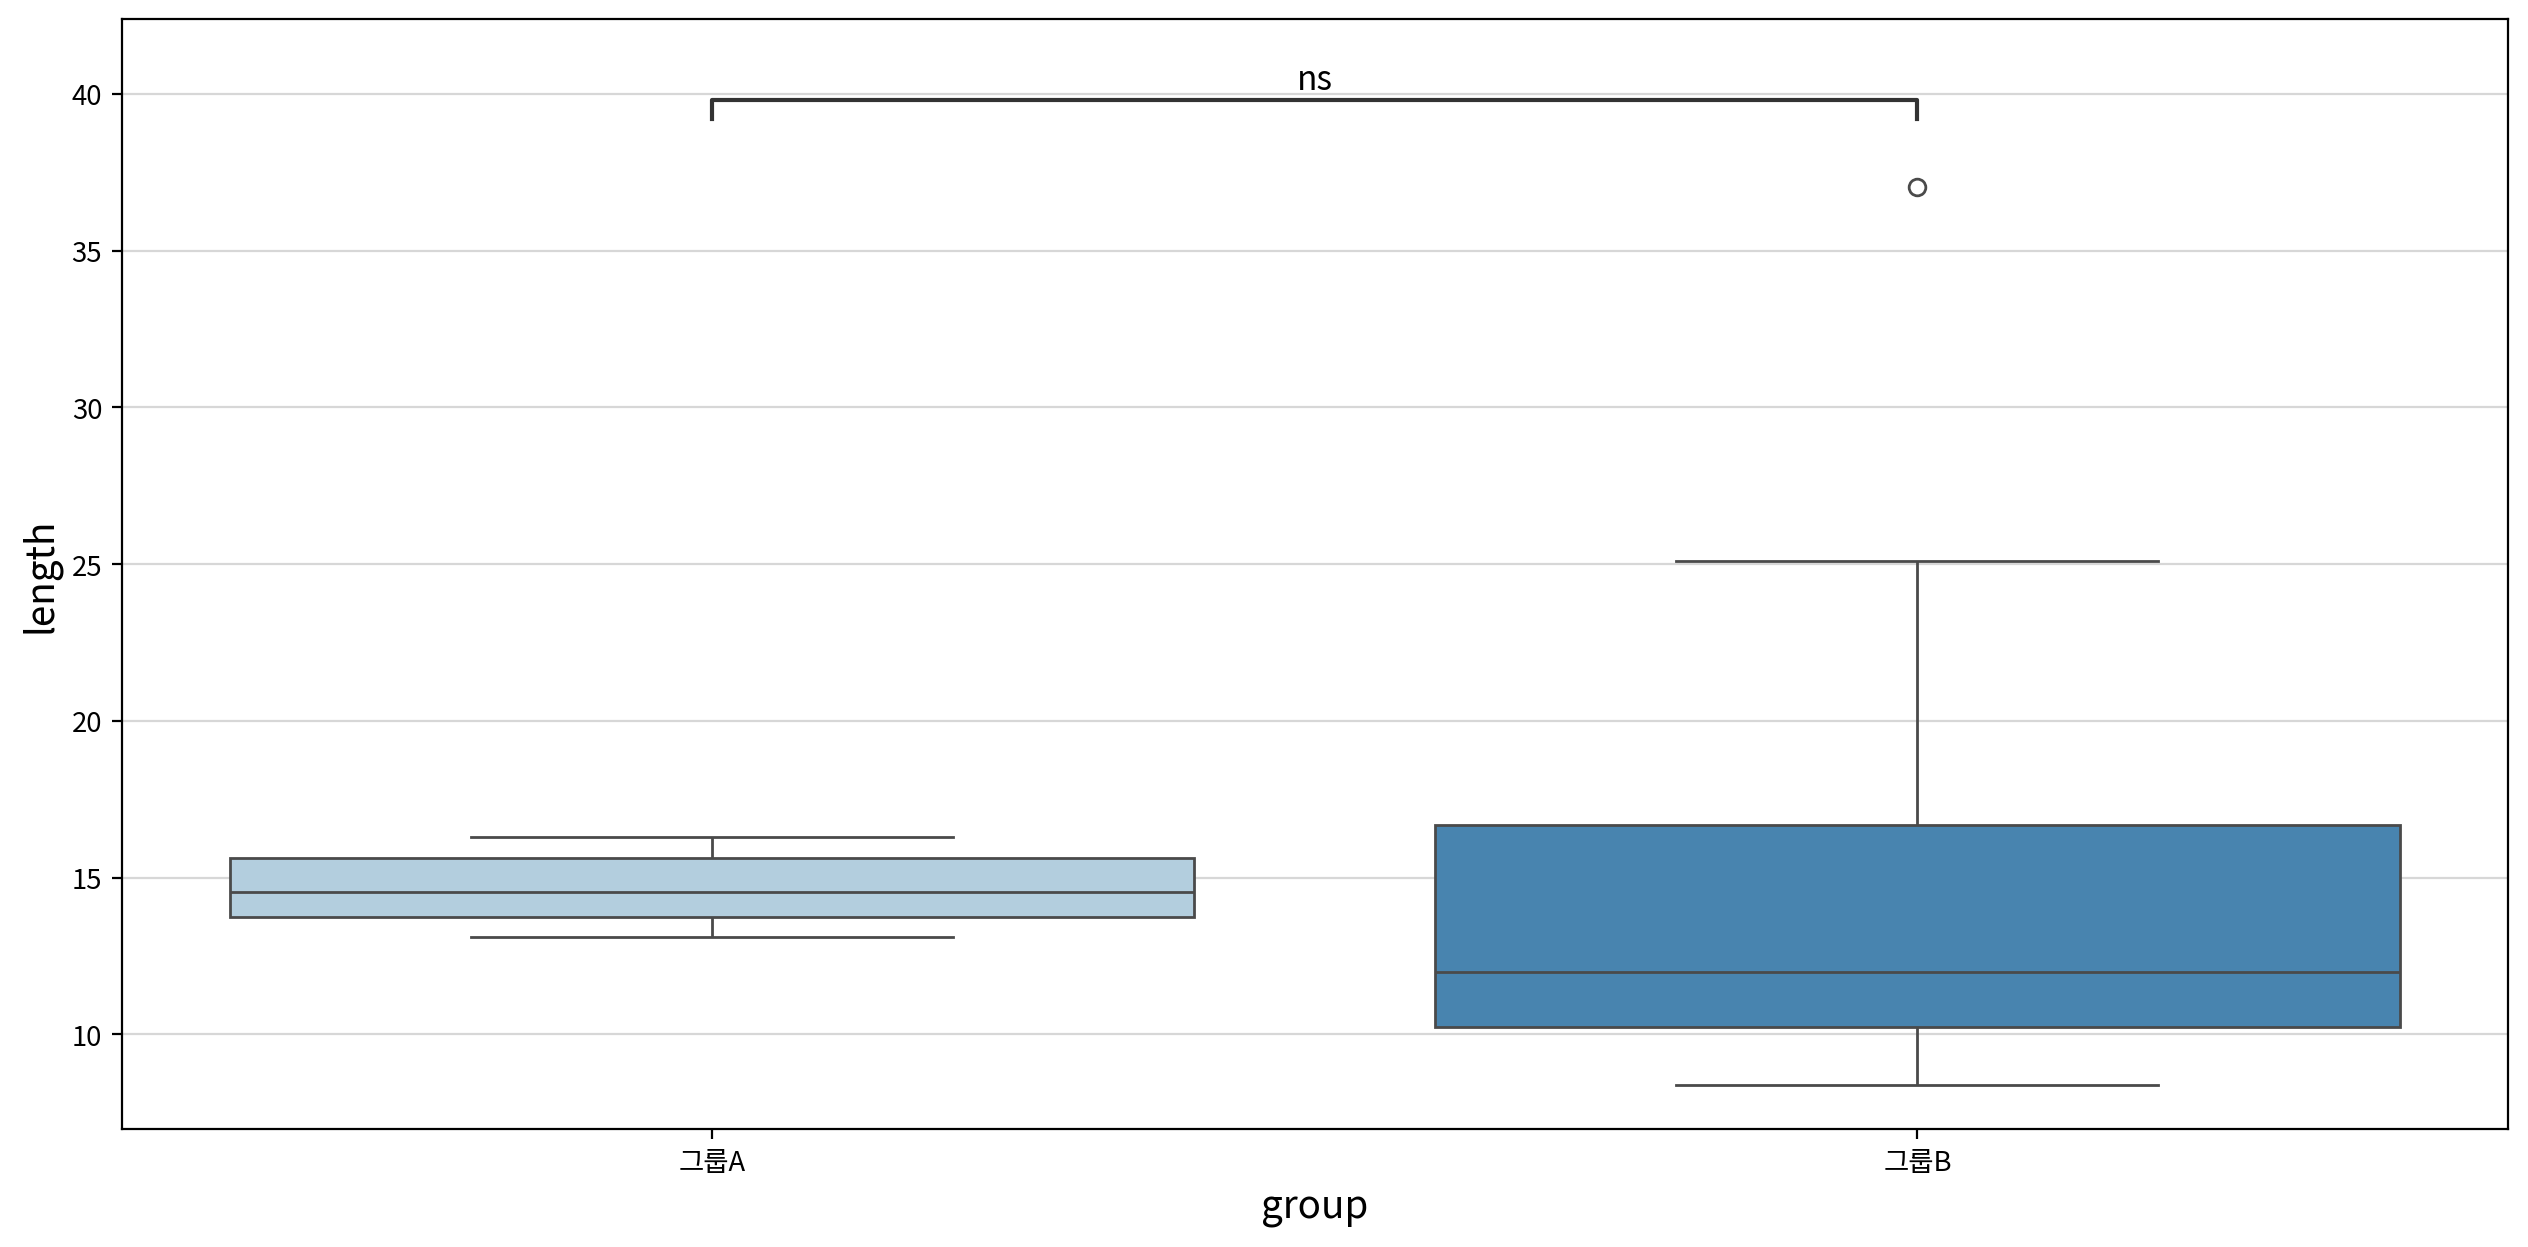

In [19]:
fig, ax = my_plot.init()
my_plot.boxplot(data=df2_melt, x='group', y='length', hue='group', palette='Blues', ax=ax)

# 독립표본 T검정 결과를 시각화에 추가
annotator = Annotator(data=df2_melt,              #데이터프레임
                      x='group',                  # x축 변수
                      y='length',                 # y축 변수
                      pairs=[('그룹A','그룹B')], #비교할 그룹 쌍
                      ax=ax)                      # 그래프 축

# 가설검정 알고리즘 종류 ('t-test_ind', 't-test-paired', 't-test_welch', 'Mann-Whitney', 'Mann-Whitney-gh', 'Mann-Whitney-ls', 'Levene', 'wilcoxon', 'Kruskal' 등을 지원)
annotator.configure(test='Wilcoxon')
annotator.apply_and_annotate()

my_plot.show()


## #04. 모듈화 기능확인
### 1. 사슴 다리 길이 비교

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

앞다리 vs. 뒷다리: t-test paired samples, P_val:7.703e-03 t=-3.414e+00


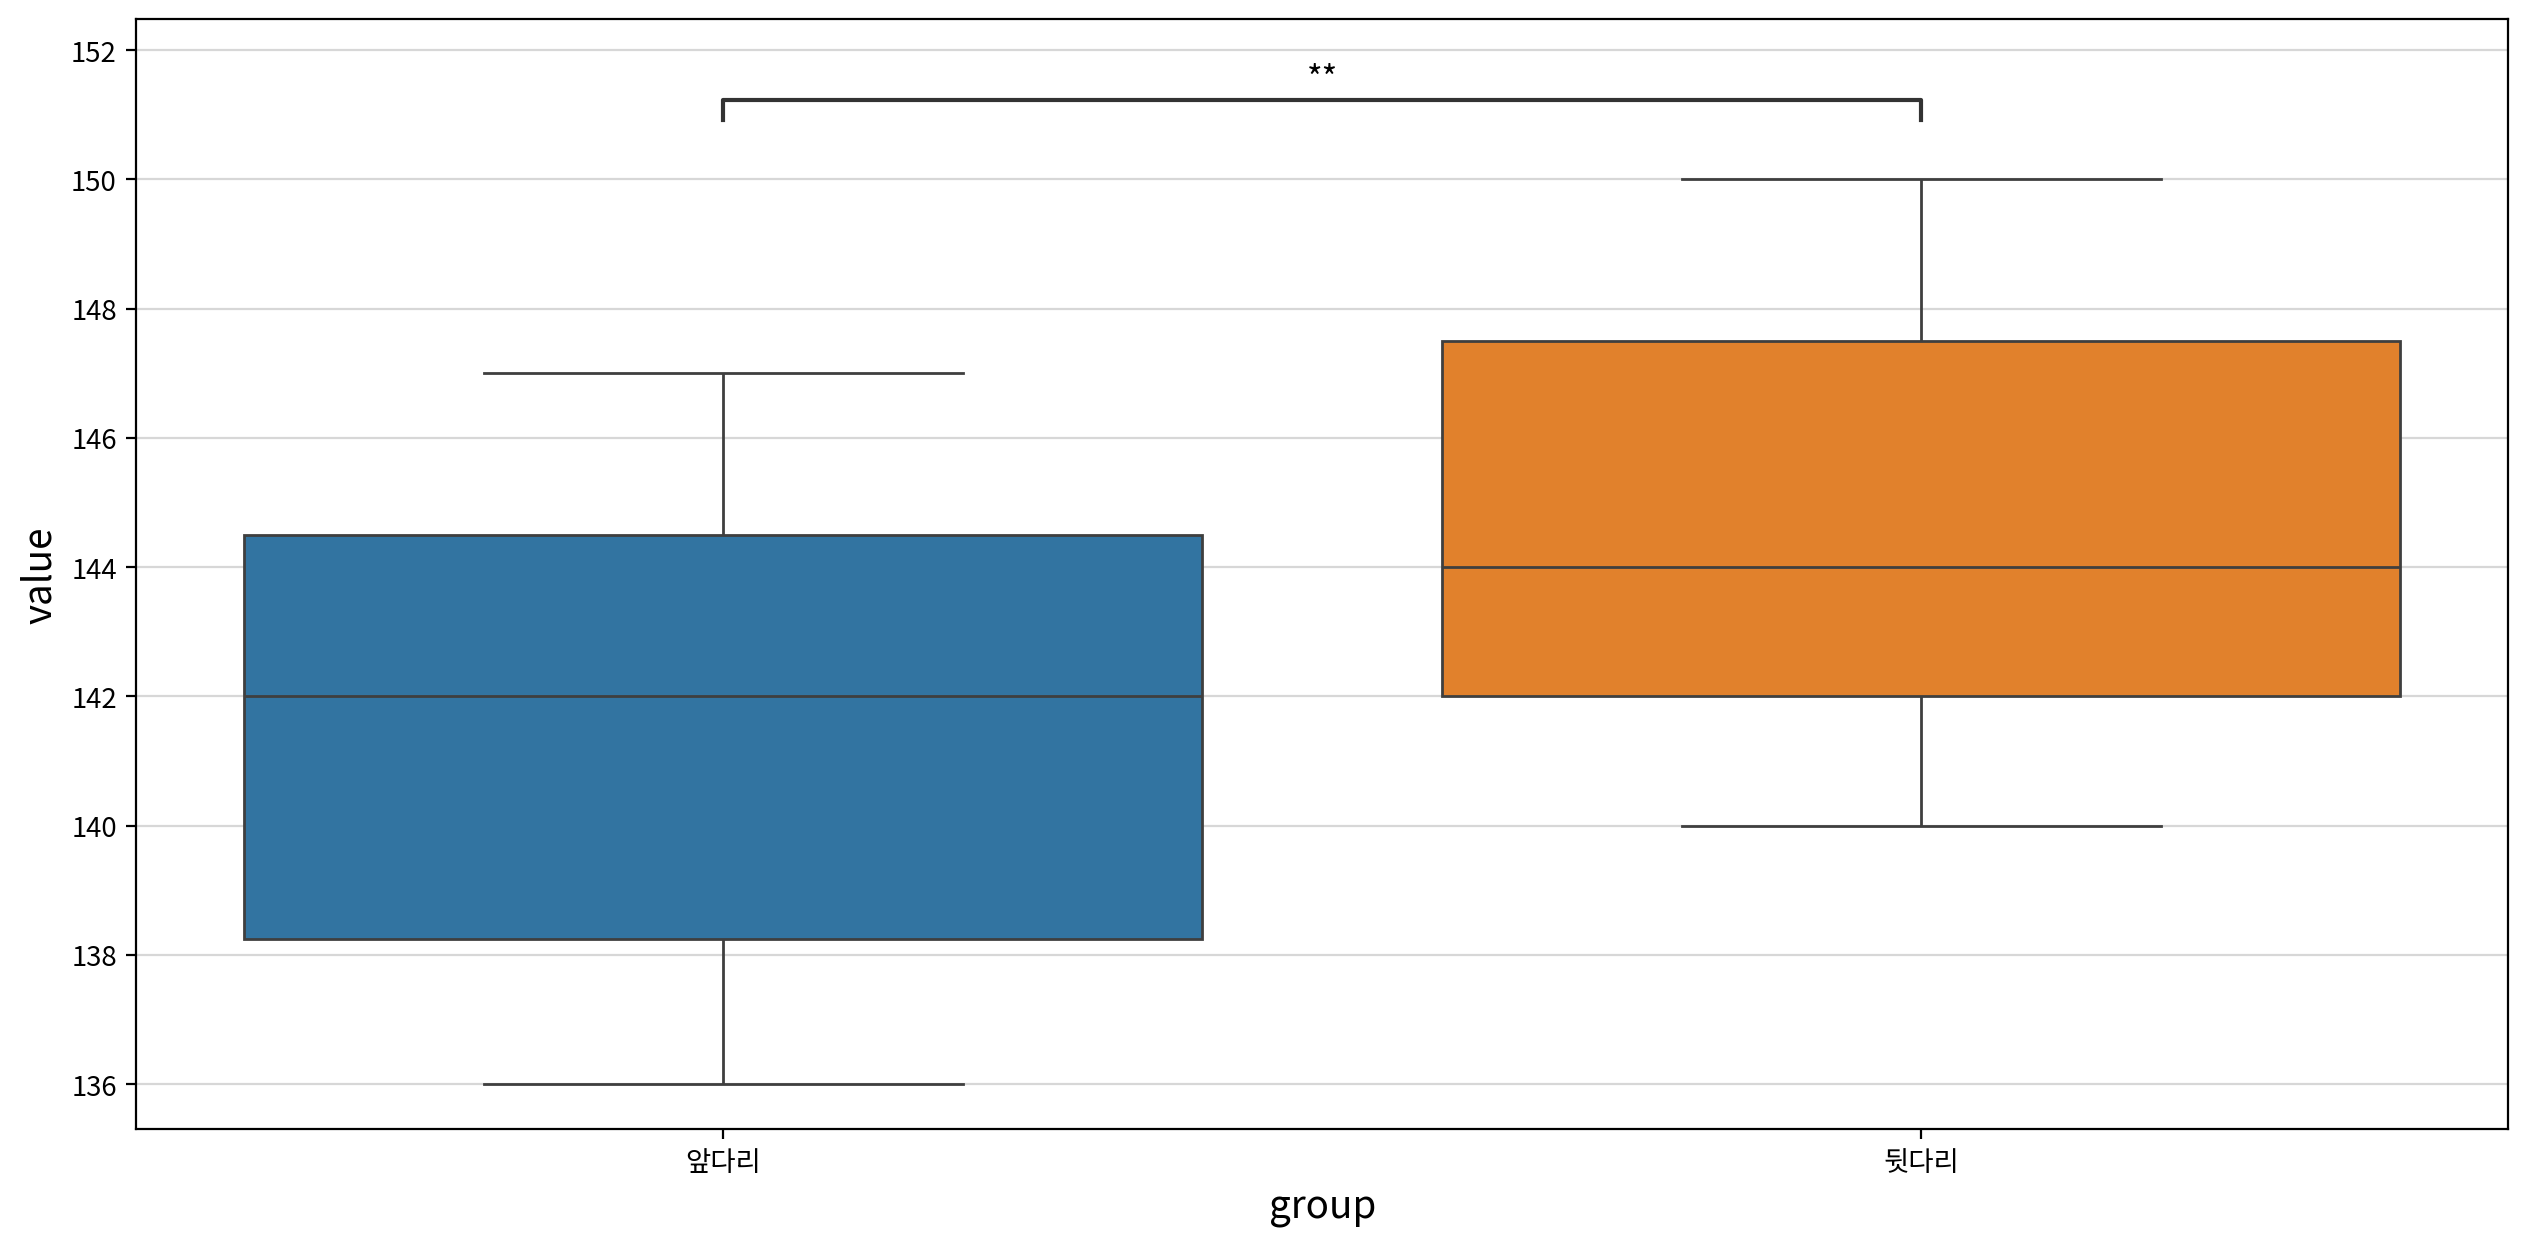

statistic  p-value  significant   result
test          alternative                                          
Paired t-test two-sided        3.414    0.008         True    차이 있음
              less             3.414    0.996        False    차이 없음
              greater          3.414    0.004         True  뒷다리>앞다리

In [20]:
my_stats.test_paired(data=df1, before='앞다리', after='뒷다리')

### 2. 자동차 첨가제가 주행거리에 미치는 영향

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

그룹A vs. 그룹B: Wilcoxon test (paired samples), P_val:7.695e-01 Stat=2.400e+01


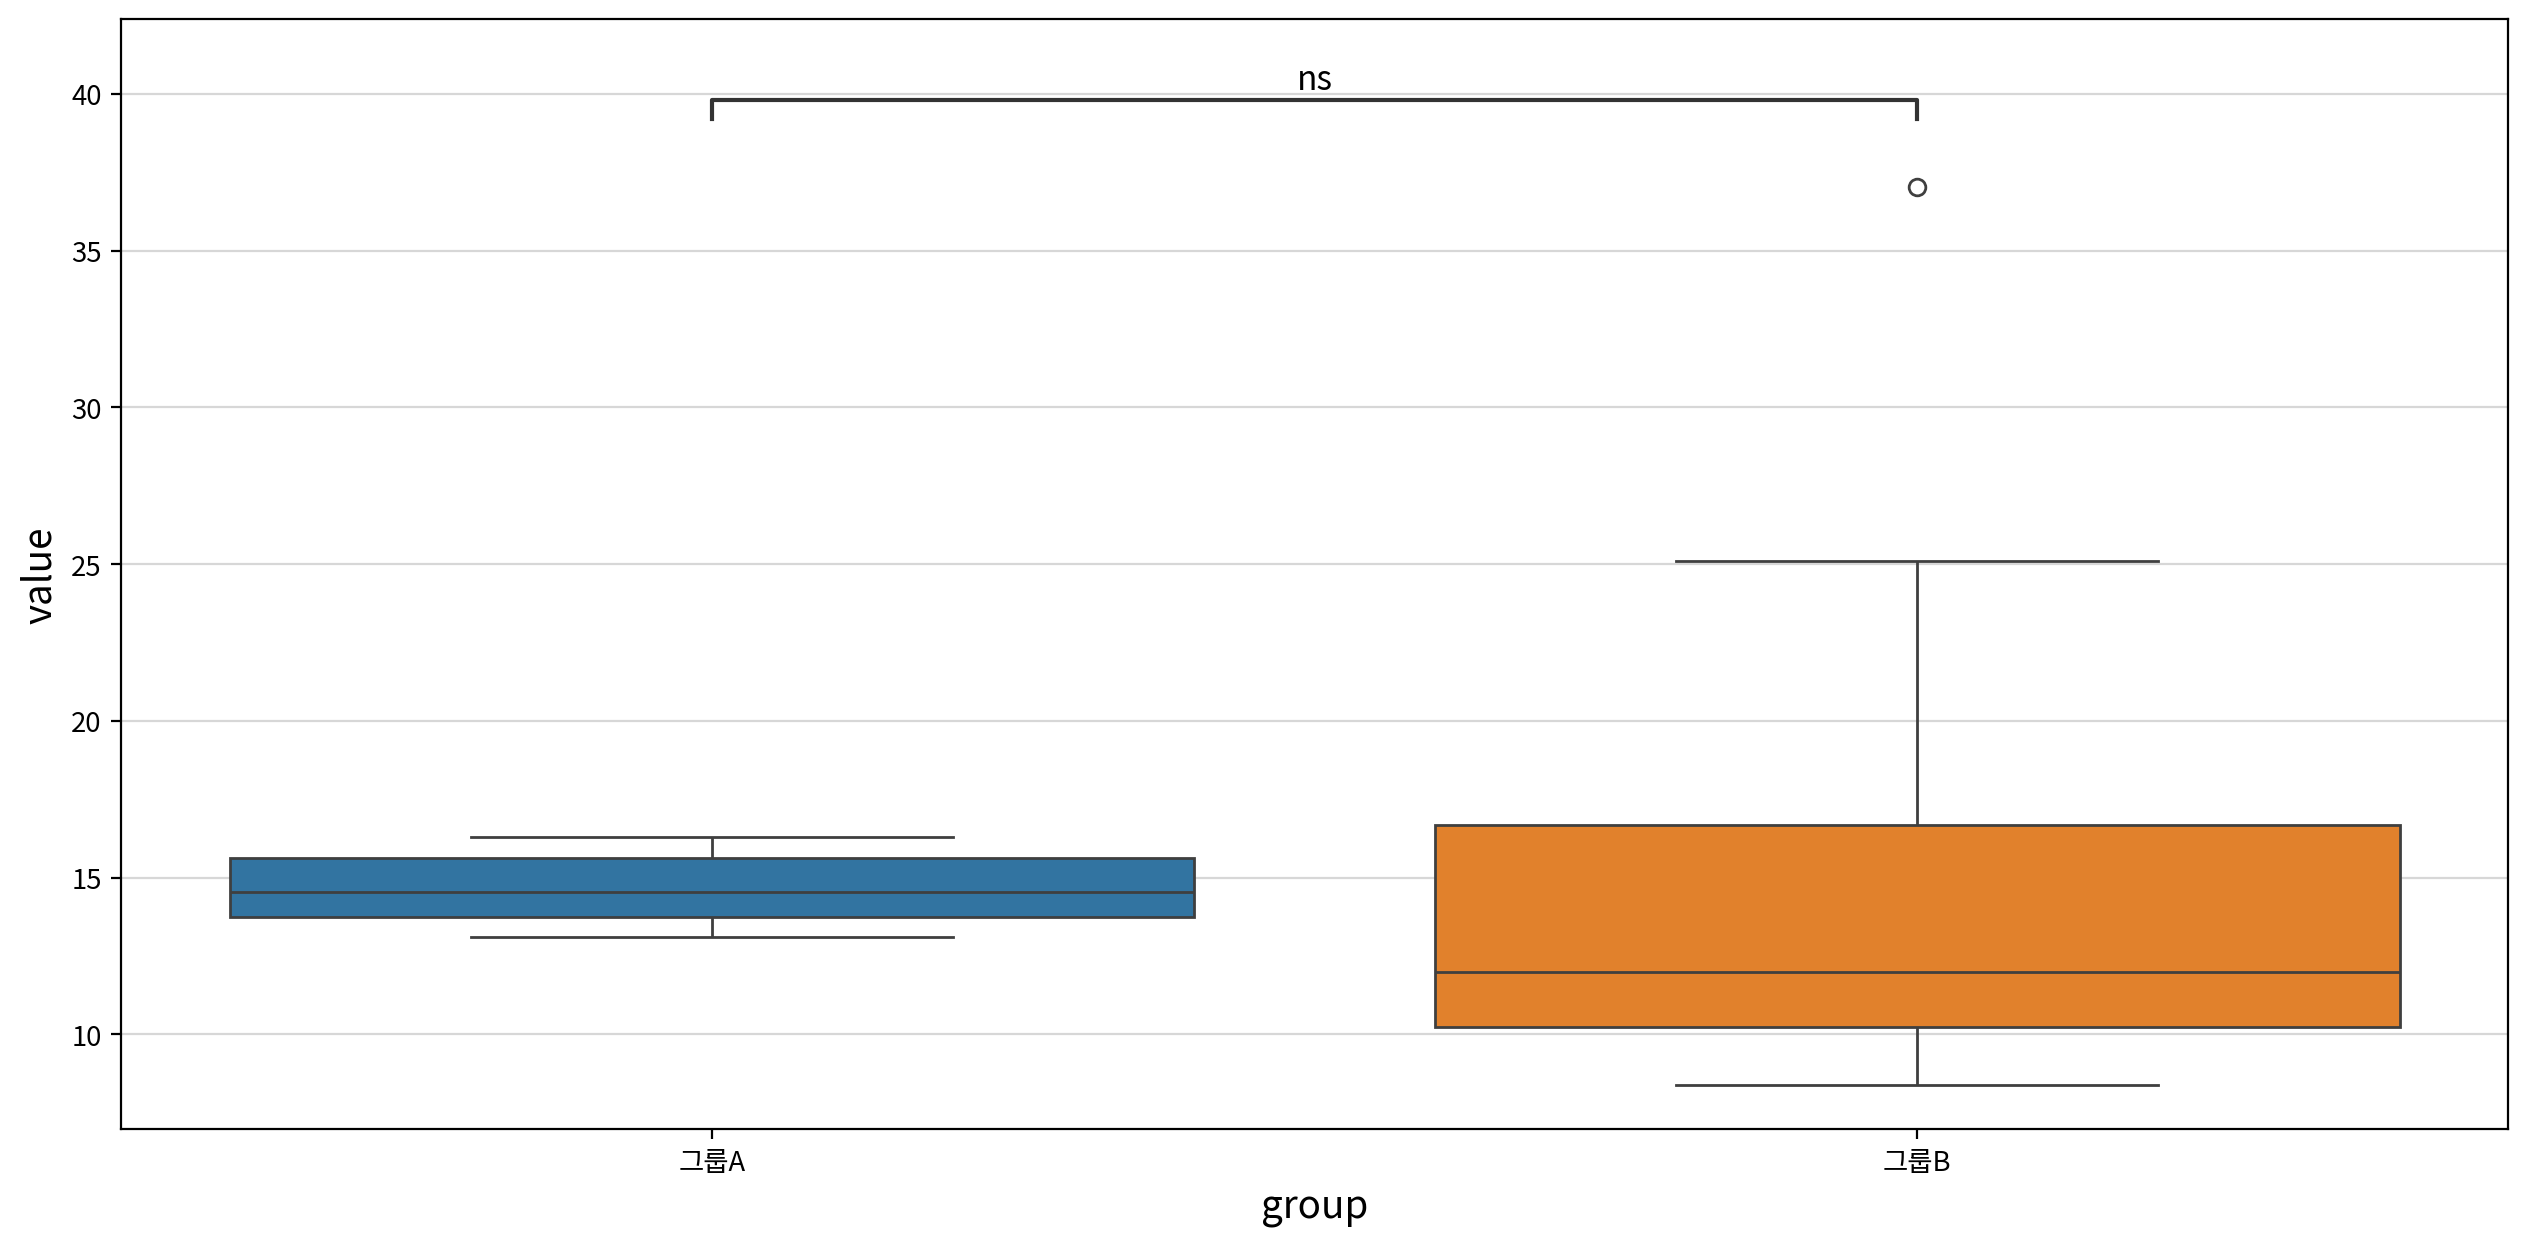

statistic  p-value  significant result
test                      alternative                                        
Wilcoxon signed-rank test two-sided       24.000    0.769        False  차이 없음
                          less            24.000    0.385        False  차이 없음
                          greater         24.000    0.652        False  차이 없음

In [21]:
my_stats.test_paired(data=df2, before='그룹A', after='그룹B')